## 1. Import required libraries

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from pickle import dump

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,auc,roc_auc_score,precision_score, roc_curve
import matplotlib.pylab as plt

## 2. Import Dataset

In [2]:
claimants_data = pd.read_csv("claimants.csv")

claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [3]:
claimants_data.shape

(1340, 7)

In [4]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Preparation

### 4.1 Data Cleaning

In [6]:
claimants_data.dropna(axis=0, inplace=True) # removed the rows if any column value is NaN

In [7]:
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [8]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

### 4.2 Seperate your inputs and outputs

In [21]:
x = claimants_data.drop(labels=["CASENUM","ATTORNEY"], axis=1)

In [22]:
x

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [23]:
y = claimants_data["ATTORNEY"]

y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5. Model Building

#### 5.1 Model Validation Techniques - Train Test Split

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle=True, random_state=50)

In [13]:
x_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
1093,1.0,1.0,0.0,10.0,5.880
833,1.0,1.0,0.0,10.0,31.005
1292,0.0,1.0,0.0,10.0,0.964
341,1.0,1.0,0.0,41.0,4.691
1125,1.0,1.0,0.0,37.0,4.609
...,...,...,...,...,...
1337,1.0,1.0,0.0,39.0,0.099
276,1.0,1.0,0.0,37.0,4.018
86,0.0,1.0,0.0,18.0,3.370
166,0.0,1.0,0.0,46.0,0.678


#### 5.2 K-Fold CV(Cross Validation)

In [14]:
from sklearn.model_selection import KFold, cross_val_score

In [33]:
kfold = KFold(n_splits=5, shuffle=True, random_state=17)

cv_scores = cross_val_score(estimator=logistic_model, X=x, y=y, cv=kfold)

print(cv_scores)
print("Overall Accuracy: ", cv_scores.mean().round(2))
print("Overall Standard Diviation: ", cv_scores.std().round(2))

[0.69545455 0.6347032  0.72146119 0.7260274  0.73059361]
Overall Accuracy:  0.7
Overall Standard Diviation:  0.04


#### 5.3 LOOCV - Leave One Out Cross Validation

In [34]:
from sklearn.model_selection import LeaveOneOut

loocv = LeaveOneOut()

cv_scores = cross_val_score(estimator=logistic_model, X=x, y=y, cv=loocv)

print(cv_scores)
print("Overall Accuracy: ", cv_scores.mean().round(2))
print("Overall Standard Diviation: ", cv_scores.std().round(2))

[1. 1. 1. ... 1. 1. 1.]
Overall Accuracy:  0.7
Overall Standard Diviation:  0.46


## 6. Model Training

In [16]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier,VotingClassifier

In [17]:
logistic_model = LogisticRegression()

In [25]:
logistic_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [68]:
rf_classifier = RandomForestClassifier(n_estimators=50, max_depth=5,criterion='gini')
rf_classifier.fit(x_train,y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
ada_boost_classifier = AdaBoostClassifier()
ada_boost_classifier.fit(x_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [17]:
from sklearn.tree import DecisionTreeClassifier

#### Stacking Techique

In [73]:
from sklearn.neighbors import KNeighborsClassifier

In [76]:
logistic_classifier = LogisticRegression()
decision_tree_classifier = DecisionTreeClassifier()
knn_classifier = KNeighborsClassifier()

voting_classifier = VotingClassifier(estimators=[("logisitic_model", logistic_classifier),
                            ("decision_tree_model", decision_tree_classifier),
                            ("knn_model", knn_classifier)])

voting_classifier.fit(x,y)

y_pred = voting_classifier.predict(x)

accuracy_score(y, y_pred)

0.8394160583941606

#### Grid Search CV(Cross Validation)

In [18]:
dt_model = DecisionTreeClassifier()

In [19]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=dt_model, param_grid={"max_depth":[5,6,7,8,9,10], "criterion": ['gini','entropy']})

grid_search.fit(x,y)

print(grid_search.best_params_)

print(grid_search.best_score_)

{'criterion': 'gini', 'max_depth': 5}
0.7253507679535076


In [66]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=rf_classifier, param_grid={"max_depth":[5,6,7,8,9,10], "criterion": ['gini','entropy'], "n_estimators":[50,75,100,150,200]})

grid_search.fit(x,y)

print(grid_search.best_params_)

print(grid_search.best_score_)

{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 50}
0.7344665836446659


In [21]:
dt_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
from sklearn.tree import plot_tree

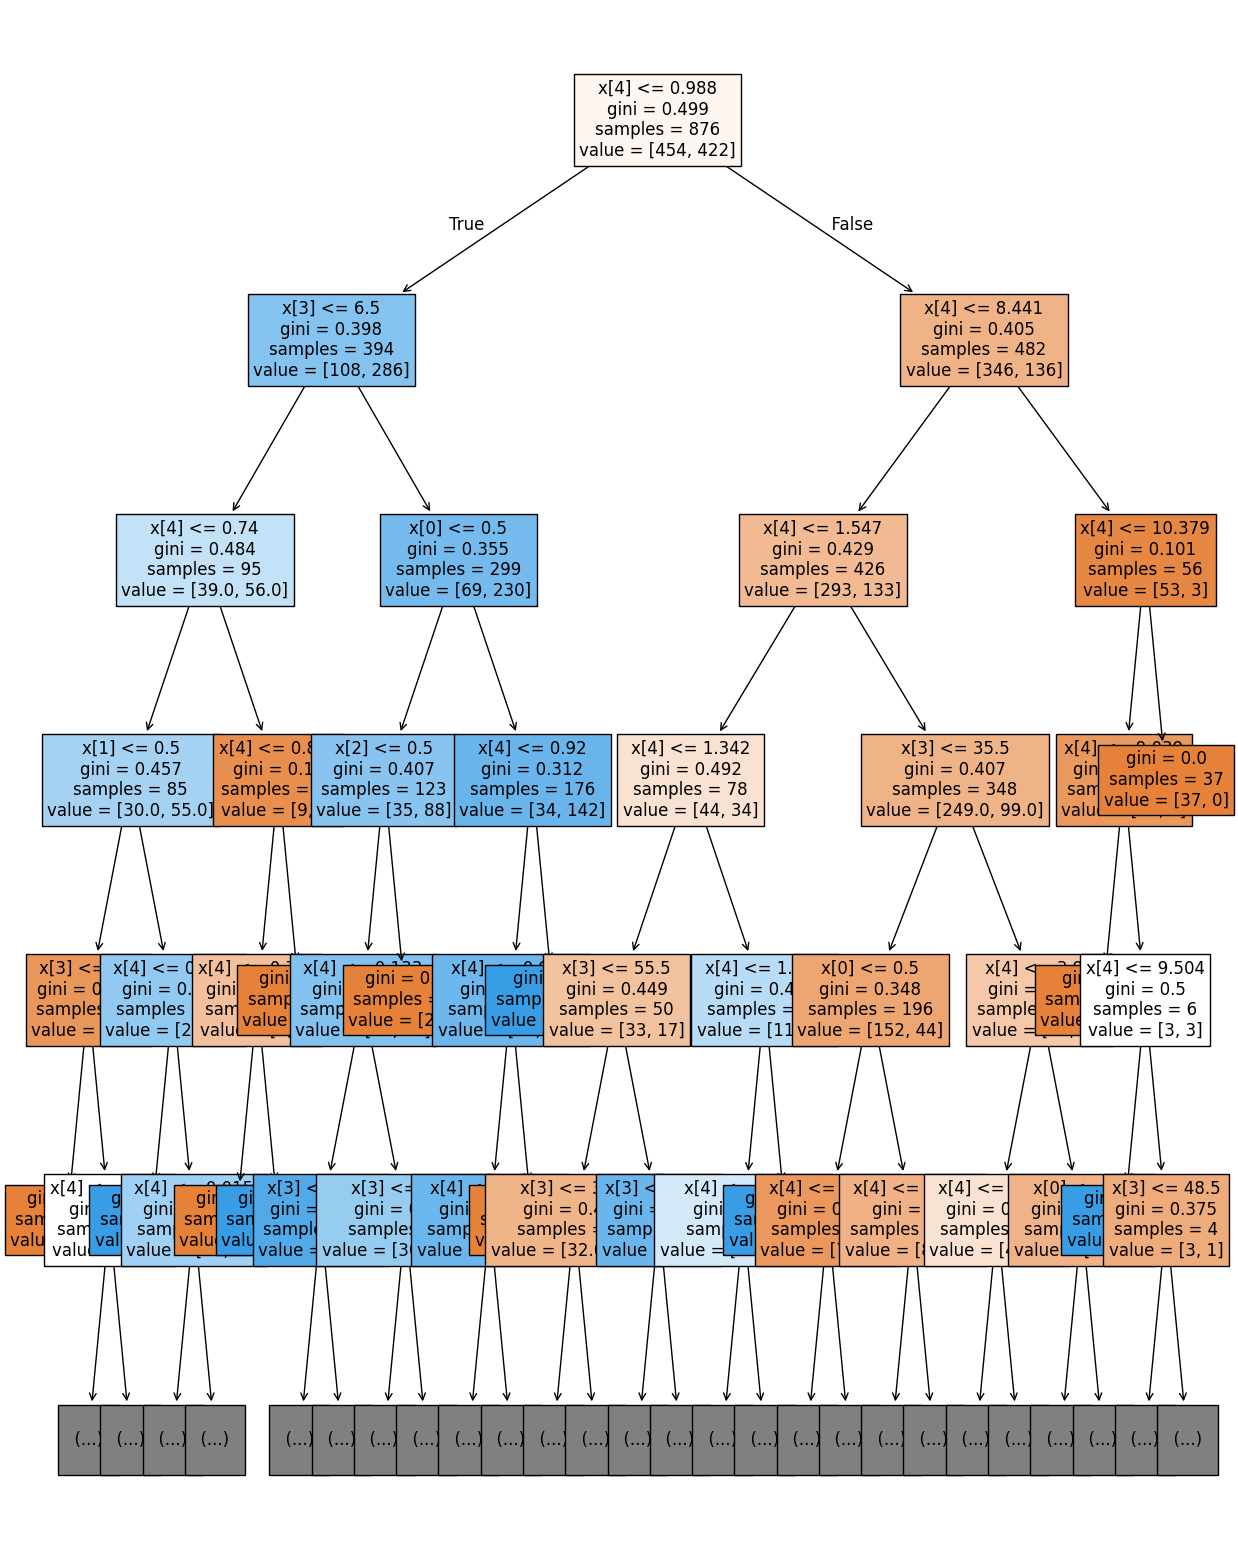

In [45]:
plt.figure(figsize=(15,20))
plot_tree(decision_tree=dt_model, fontsize=12, filled=True, max_depth=5)
plt.show()

## 7. Model Training

#### Training Data

In [54]:
y_pred_train = rf_classifier.predict(x_train)

y_pred_train

array([0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,

#### Test Data

In [55]:
y_pred_test = rf_classifier.predict(x_test)
y_pred_test

array([0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1])

In [56]:
claimants_data["Predicted_Output"] = logistic_model.predict(x)

claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Predicted_Output
0,5,0,0.0,1.0,0.0,50.0,34.940,0
1,3,1,1.0,0.0,0.0,18.0,0.891,1
2,66,1,0.0,1.0,0.0,5.0,0.330,1
3,70,0,0.0,1.0,1.0,31.0,0.037,1
4,96,1,0.0,1.0,0.0,30.0,0.038,1
...,...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060,1
1336,34110,0,1.0,1.0,0.0,46.0,3.705,0
1337,34113,1,1.0,1.0,0.0,39.0,0.099,1
1338,34145,0,1.0,0.0,0.0,8.0,3.177,0


## 8. Model Evaluation

#### 8.1 Training Data's Evaluation Metrics

In [57]:
print(confusion_matrix(y_train, y_pred_train))

[[362  92]
 [129 293]]


In [58]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.74      0.80      0.77       454
           1       0.76      0.69      0.73       422

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



#### ROC Curve - Receiver Operating Characteristics

#### AUC - Area Under this Curve

0.7458348122011816


Text(0, 0.5, 'True Positive Rate')

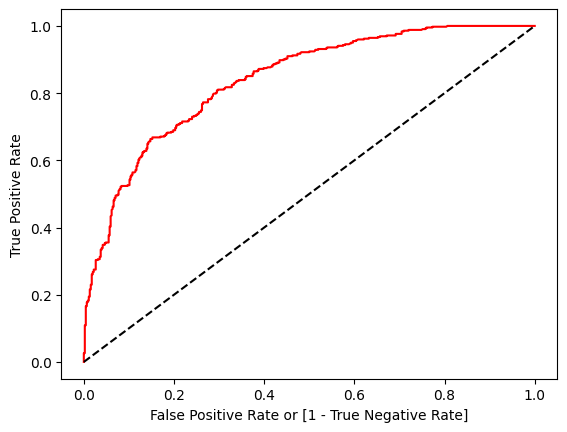

In [59]:
fpr, tpr, thresholds = roc_curve(y_train, rf_classifier.predict_proba(x_train)[:,1])

auc = roc_auc_score(y_train, y_pred_train)

print(auc)


plt.plot(fpr, tpr, color="red", label="Logit Model (area = %0.2f)"%auc)
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate or [1 - True Negative Rate]")
plt.ylabel("True Positive Rate")

In [60]:
accuracy_score(y_train, y_pred_train)

0.747716894977169

#### 8.2 Test Data's Evaluation Metrics

In [61]:
accuracy_score(y_test, y_pred_test)

0.7363636363636363

In [62]:
print(confusion_matrix(y_test, y_pred_test))

[[91 33]
 [25 71]]


In [63]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.78      0.73      0.76       124
           1       0.68      0.74      0.71        96

    accuracy                           0.74       220
   macro avg       0.73      0.74      0.73       220
weighted avg       0.74      0.74      0.74       220



0.7367271505376345


Text(0, 0.5, 'True Positive Rate')

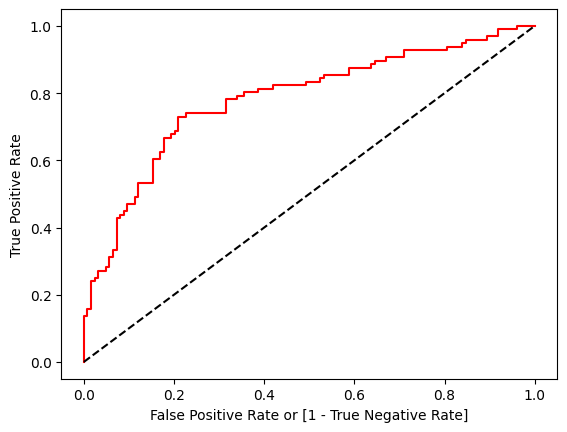

In [65]:
fpr, tpr, thresholds = roc_curve(y_test, rf_classifier.predict_proba(x_test)[:,1])

auc = roc_auc_score(y_test, y_pred_test)

print(auc)

import matplotlib.pylab as plt
plt.plot(fpr, tpr, color="red", label="Logit Model (area = %0.2f)"%auc)
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate or [1 - True Negative Rate]")
plt.ylabel("True Positive Rate")

#### This model got Overfitted

#### Note:

- We always expect GENERALIZED Model

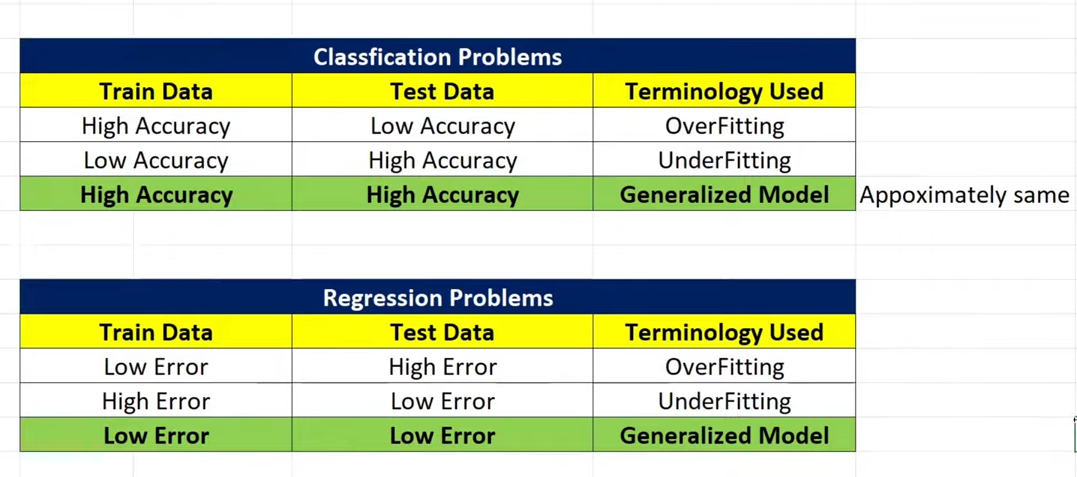


### BIAS - VARIANCE

- Training Error/Accuracy - Bias
- Test Errir/Accurancy - Variance

#### Model Overfitting - Less Bias and High Variance
#### Model Underfitting - High Bias and Less Variance

### EXPECTED MODEL - GENERALIZED MODEL - Less Bias and Less Variance

So, there is always a **Tradeoff maintained between Bias and Variance**



## 9. Model Deployment

In [40]:
dump(logistic_model, open("claimants.pkl", mode="wb"))

## THE END !!!